# ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics           import (accuracy_score, f1_score, roc_auc_score, auc , confusion_matrix, classification_report,roc_curve, precision_recall_curve)
import xgboost as xgb

In [2]:
df = pd.read_csv('ml_dataset.csv')
display(df.head(5))

,Type,Late_delivery_risk,Customer Segment,Department Name,Shipping Mode,order_month,order_hour,is_weekend,is_peak_hour,Order Region_freq,Category Name_freq
0,DEBIT,0,Consumer,Fitness,Standard Class,1,22,0,0,0.052881,0.001945
1,TRANSFER,1,Consumer,Fitness,Standard Class,1,12,1,1,0.043151,0.001945
2,CASH,0,Consumer,Fitness,Standard Class,1,12,1,1,0.043151,0.001945
3,DEBIT,0,Home Office,Fitness,Standard Class,1,11,1,1,0.056337,0.001945
4,PAYMENT,0,Corporate,Fitness,Standard Class,1,11,1,1,0.056337,0.001945


In [3]:
x = df[
    ['Type', 'Customer Segment', 'Department Name',
     'Shipping Mode', 'order_month', 'order_hour',
     'is_weekend', 'is_peak_hour',
     'Order Region_freq', 'Category Name_freq']
]

y = df['Late_delivery_risk']

categorical_col = ['Type'  , 'Customer Segment','Department Name','Shipping Mode']

numeric_col = [c for c in x.columns if c not in categorical_col]

print(f"\n  Numerical features   : {len(numeric_col)} -> {numeric_col}")
print(f"  Categorical features : {len(categorical_col)}  → {categorical_col}")


  Numerical features   : 6 -> ['order_month', 'order_hour', 'is_weekend', 'is_peak_hour', 'Order Region_freq', 'Category Name_freq']
  Categorical features : 4  → ['Type', 'Customer Segment', 'Department Name', 'Shipping Mode']


In [4]:
x_train , x_test , y_train , y_test = train_test_split(x , y , random_state=42 , test_size=0.3 , stratify=y)
print(f"train shape : {x_train.shape} : {y_train.shape}")
print(f"test shape : {x_test.shape} : {y_test.shape}")

train shape : (120935, 10) : (120935,)
test shape : (51830, 10) : (51830,)


In [5]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_col),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_col),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [6]:
pipelines = {

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", xgb.XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ])
}
for name, pipe in pipelines.items():
    print(f"\nTraining {name}...")
    pipe.fit(x_train, y_train)


Training Logistic Regression...

Training Random Forest...

Training XGBoost...


In [7]:
results = []

for name, pipe in pipelines.items():

    y_pred = pipe.predict(x_test)
    accuracy =  accuracy_score(y_test , y_pred)
    y_prob = pipe.predict_proba(x_test)[:, 1]

    roc = roc_auc_score(y_test, y_prob)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "accuracy_score" : accuracy,
        "Precision": round(report['1']['precision'], 4),
        "Recall": round(report['1']['recall'], 4),
        "F1": round(report['1']['f1-score'], 4),
        "AUC-ROC": round(roc, 4),
        "PR-AUC": round(pr_auc, 4)
    })

    print(f"\n{name}")
    print("AUC-ROC:", roc)
    print("accuracy_score" , accuracy)
    print("PR-AUC :", pr_auc)
    print(confusion_matrix(y_test, y_pred))
    print(f"classification report : \n {classification_report(y_test , y_pred)}")


Logistic Regression
AUC-ROC: 0.7449838577210399
accuracy_score 0.6973567431989195
PR-AUC : 0.8375779724939257
[[20092  2045]
 [13641 16052]]
classification report : 
               precision    recall  f1-score   support

           0       0.60      0.91      0.72     22137
           1       0.89      0.54      0.67     29693

    accuracy                           0.70     51830
   macro avg       0.74      0.72      0.70     51830
weighted avg       0.76      0.70      0.69     51830


Random Forest
AUC-ROC: 0.7894626587571494
accuracy_score 0.7238278989002508
PR-AUC : 0.8639926286319803
[[20092  2045]
 [12269 17424]]
classification report : 
               precision    recall  f1-score   support

           0       0.62      0.91      0.74     22137
           1       0.89      0.59      0.71     29693

    accuracy                           0.72     51830
   macro avg       0.76      0.75      0.72     51830
weighted avg       0.78      0.72      0.72     51830


XGBoost
AUC-ROC

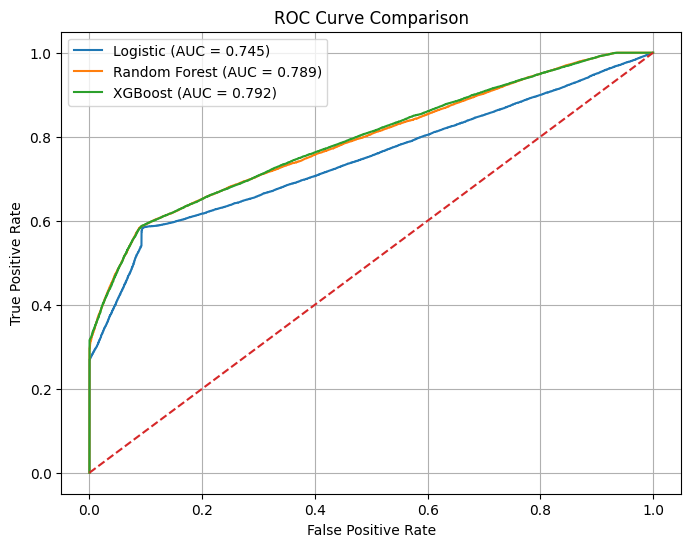

In [8]:
# get probability
log_prob = pipelines['Logistic Regression'].predict_proba(x_test)[:,1]

rf_prob = pipelines['Random Forest'].predict_proba(x_test)[:,1]

xgb_prob = pipelines['XGBoost'].predict_proba(x_test)[:,1]

# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _   = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

# AUC score
auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [9]:
print("\n===== CROSS VALIDATION =====\n")

cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, x, y, cv=skf, scoring='roc_auc')

    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std Dev": scores.std()
    })

    print(f"{name}")
    print("Mean ROC-AUC:", scores.mean())
    print("Std:", scores.std())
    print("-" * 40)

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean ROC-AUC", ascending=False)
print("\nFinal CV Comparison:")
print(cv_results_df)    


===== CROSS VALIDATION =====

Logistic Regression
Mean ROC-AUC: 0.7441647059970187
Std: 0.0028769438646516136
----------------------------------------
Random Forest
Mean ROC-AUC: 0.7895622046229674
Std: 0.0019244073510090868
----------------------------------------
XGBoost
Mean ROC-AUC: 0.7937671926597254
Std: 0.0014176855875756306
----------------------------------------

Final CV Comparison:
                 Model  Mean ROC-AUC   Std Dev
2              XGBoost      0.793767  0.001418
1        Random Forest      0.789562  0.001924
0  Logistic Regression      0.744165  0.002877


In [10]:
import joblib

# Step 1: Find best model by AUC-ROC
results_df = pd.DataFrame(results)
# best_model_name = results_df.loc[results_df["AUC-ROC"].idxmax(), "Model"]
best_model_name = cv_results_df.iloc[0]["Model"]
print(f"Best Model : {best_model_name}  (AUC-ROC = {results_df['AUC-ROC'].max()})")

# Step 2: Save best pipeline as .pkl
best_pipeline = pipelines[best_model_name]
filename = f"models/best_model.pkl"
joblib.dump(best_pipeline, filename)
print(f"✅ Best model saved successfully as:")
print(f"   📁 {filename}")
print(f"   Model Type: {best_model_name}")

Best Model : XGBoost  (AUC-ROC = 0.7917)
✅ Best model saved successfully as:
   📁 models/best_model.pkl
   Model Type: XGBoost


In [12]:
df.head(2)

,Type,Late_delivery_risk,Customer Segment,Department Name,Shipping Mode,order_month,order_hour,is_weekend,is_peak_hour,Order Region_freq,Category Name_freq
0,DEBIT,0,Consumer,Fitness,Standard Class,1,22,0,0,0.052881,0.001945
1,TRANSFER,1,Consumer,Fitness,Standard Class,1,12,1,1,0.043151,0.001945


# test model

In [22]:
model_path = 'models/best_model.pkl'

try:
    model = joblib.load(model_path)
    print("✅ Model loaded successfully!")
    print(f"   Loaded Model: {model_path}")
except FileNotFoundError:
    print("❌ Model file not found! Please check the path.")
    print("Make sure you ran the training code and saved the model first.")

def predict_delivery_risk(input_dict):
    """Make prediction from a dictionary input"""
    sample = pd.DataFrame([input_dict])
    pred = best_pipeline.predict(sample)[0]
    prob = best_pipeline.predict_proba(sample)[:, 1][0]
    
    reaction = "On_time_delivery" if pred == 1 else "Late Delivery"
    print(f"late Delivery prediction : {'🟢 on time delivery' if pred == 1 else '🔴 late delivery'}")
    print(f"Probability    : {prob:.4f} ({prob*100:.2f}%)")
    return reaction, prob

# Example usage:
test_case = {
    'Type': 'Debit',
    'Customer Segment': 'Consumer',
    'Department Name': 'Infra/Hardware',
    'Shipping Mode' : 'Standard Class',
    'order_month' : 4 , 
    'order_hour' : 2 , 
    'is_weekend' : 1,
    'is_peak_hour' : 0,
    'Order Region_freq' : 0.052882,
    'Category Name_freq' : '0.001295'
}

predict_delivery_risk(test_case)

✅ Model loaded successfully!
   Loaded Model: models/best_model.pkl
late Delivery prediction : 🔴 late delivery
Probability    : 0.4580 (45.80%)


('Late Delivery', np.float32(0.45796034))